In [1]:
#IMPORTS
import pandas as pd
import numpy as np
from skbio.stats.composition import clr
from scipy.stats import pearsonr
from typing import List, Tuple, Optional, Union
import seaborn as sns
import matplotlib.pyplot as plt
import re

In [2]:
#FUNCTION DEFINITIONS
def calc_pearson(df, input_vars: List[Union[int,float]]):
    """
    Parameters:
    df[MxN]: dataframe containing various observations which are to be correlated to an input sequence
    input_var[1xN]: the input sequence
    
    The input DataFrame must only include the columns for the observations which are correlated to the input sequence. The input array should also have no all-zero rows.

    Returns: A df with columns r_value and p_values corresponding to significance and Pearson R correlation with input_var for each observation
    and df.index.
    """
    assert df.shape[1] == len(input_vars)
    
    results=[]
    
    for idx, row in df.iterrows():
        vals = row.values
        r_value, p_value = pearsonr(input_vars, vals)
        results.append([r_value, p_value])
        
    corr_df = pd.DataFrame(results, columns=["r_value","p_value"],index=df.index)

    return corr_df

In [3]:
#CONSTANTS
VOLTAGES = [0, 200, 400, 600, 800]
TAXA = ['domain','phylum','class','order','family','genus','species']
FILTERS = [".*10m.*",".*20_5m.*",".*35m.*"]
DEPTHS = ["10m","20.5m","35m"]

In [31]:
#READ DATA
complete = pd.read_excel("MLEA_111724_otu_table_complete.xlsx", index_col=0)
dtype_mapping = {
    'numeric': float,
    'categorical': str
}
dtypes = dict(zip(complete.columns.tolist(), [dtype_mapping[dtype] for dtype in complete.iloc[0]]))
complete = pd.read_excel("MLEA_111724_otu_table_complete.xlsx", index_col=0, dtype=dtypes, skiprows=[1])
complete['Taxon'] = complete['Taxon'].str.split("; ")
#BREAK OUT TAXONOMIC LEVLES INTO THEIR OWN COLUMNS FOR CLASSIFICATION
values = []
for taxon in complete['Taxon']:
    for i in range(7-len(taxon)):
        taxon.append('na')
    for i, value in enumerate(taxon):
        if not re.match(r'.*__[A-Z].*',value):
            taxon[i] = 'na'
        else:
            taxon[i] = taxon[i][3:]
    values.append(taxon)
df_taxa = pd.DataFrame(values, index=complete.index, columns=TAXA).join(complete)
df_taxa.head()

,domain,phylum,class,order,family,genus,species,Taxon,Consensus,Sequence,...,GL_111724_20_5m_400_V,GL_111724_20_5m_600_V,GL_111724_20_5m_800_V,GL_111724_20_5m_Cnt_V,GL_111724_35m_0_V,GL_111724_35m_200_V,GL_111724_35m_400_V,GL_111724_35m_600_V,GL_111724_35m_Cnt_V,GL_111724_AncElec_V
id,,,,,,,,,,,,,,,,,,,,,
00009bf207093f9faba405063b3bd168,Bacteria,Proteobacteria,Alphaproteobacteria,Caedibacterales,Caedibacteraceae,Caedibacter,na,"[Bacteria, Proteobacteria, Alphaproteobacteria...",1,TGGGGAATCTTGGACAATGGGGGCAACCCTGATCCAGCGATGCCGC...,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
00066c1bd7faac09db9ee4418f8c9133,Bacteria,Planctomycetota,Planctomycetes,Pirellulales,Pirellulaceae,Pirellula,na,"[Bacteria, Planctomycetota, Planctomycetes, Pi...",0.6,TCGAGAATCTTCGGCAATGGGCGAAAGCCTGACCGAGCGACGCCGC...,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0006bcf50d74e3d3362657f3e7f98bb3,Bacteria,Verrucomicrobiota,Verrucomicrobiae,Chthoniobacterales,Chthoniobacteraceae,Chthoniobacter,na,"[Bacteria, Verrucomicrobiota, Verrucomicrobiae...",0.6,TCGAGAATTTTTCTCAATGGGGGAAACCCTGAAGGAGCGACGCCGC...,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0009e38c9cbd071a9403ea04c4e169b1,Bacteria,Bacteroidota,Bacteroidia,Chitinophagales,Saprospiraceae,na,na,"[Bacteria, Bacteroidota, Bacteroidia, Chitinop...",1,TAAGGAATATTGGACAATGGTCGGAAGACTGATCCAGCCATGCCGC...,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0010c9ded97ac64f27db502a4a174415,Bacteria,Proteobacteria,Alphaproteobacteria,na,na,na,na,"[Bacteria, Proteobacteria, Alphaproteobacteria...",0.7,TGGGGAATATTGGACAATGGGGGCAACCCTGATCCAGCCATGCCGC...,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [32]:
# CREATE 21 DATA FRAMES SUMMARIZED BY TAXON LEVEL, WITH PEARSON R-CORRELATION BETWEEN CLR-VALUES AND VOLTAGES BY DEPTH
# CALCULATES PEARSON CORRELATION OF CLR VALUES WITH VOLTAGES, BY DEPTH
def calc_pearson_by_depth(df):
    results=[]
    
    for f in FILTERS:
        filter_df = df.filter(regex=f)
        pearson_df = calc_pearson(filter_df.iloc[:,:-1], VOLTAGES[:(filter_df.shape[1]-1)])
        result = filter_df.join(pearson_df)
        result.insert(loc=0,column='Unique ASVs',value=df['Unique ASVs'])
        results.append(result)

    results = dict(zip(DEPTHS,results))
    return results

# CREATES A NESTED DICTIONARY OF DATAFRAMES GROUPED FIRST BY TAXONOMIC LEVEL, THEN BY DEPTH.
# EACH DF CONTAINS CLR-VALUES BY VOLTAGE, R-VALUE, P-VALUE, AND UNIQUE ASVS
def group_by_taxa(df):
    results=[]
    
    for taxa in TAXA:
        grouped = df.groupby(taxa).sum(numeric_only=True)
        grouped = pd.DataFrame(clr(grouped+1,axis=0),index=grouped.index,columns=grouped.columns)
        grouped.insert(loc=0,column="Unique ASVs",value=list(df.groupby(taxa).size()))
        results.append(calc_pearson_by_depth(grouped))
    
        
    return results

grouped_by_taxa = dict(zip(TAXA,group_by_taxa(df_taxa)))

In [24]:
grouped_by_taxa['phylum']['10m']

,Unique ASVs,GL_111724_10m_0_V,GL_111724_10m_200_V,GL_111724_10m_400_V,GL_111724_10m_600_V,GL_111724_10m_800_V,GL_111724_10m_Cnt_V,r_value,p_value
phylum,,,,,,,,,
Acetothermia,2,-3.931187,-3.878712,-3.500591,-3.587190,-3.738278,-3.205623,0.581578,0.303681
Acidobacteriota,410,4.266076,4.130319,3.867117,4.023663,4.224834,3.987311,-0.185362,0.765348
Actinobacteriota,607,6.284480,6.171470,6.170144,6.643801,6.660302,5.599452,0.782567,0.117659
Aenigmarchaeota,1,-3.931187,-2.086952,-3.500591,-3.587190,-3.738278,-3.205623,-0.239730,0.697716
Altiarchaeota,1,-3.931187,-3.878712,-3.500591,-3.587190,-3.738278,-3.205623,0.581578,0.303681
...,...,...,...,...,...,...,...,...,...
WPS-2,9,1.086092,0.503315,0.610282,-0.814601,-0.127360,0.532047,-0.804123,0.100953
WS2,6,-3.931187,-1.480816,-3.500591,0.675490,-1.435693,-1.819329,0.610499,0.274116
WS4,5,-3.931187,-3.878712,-0.281716,-3.587190,-0.480181,-3.205623,0.605626,0.279041


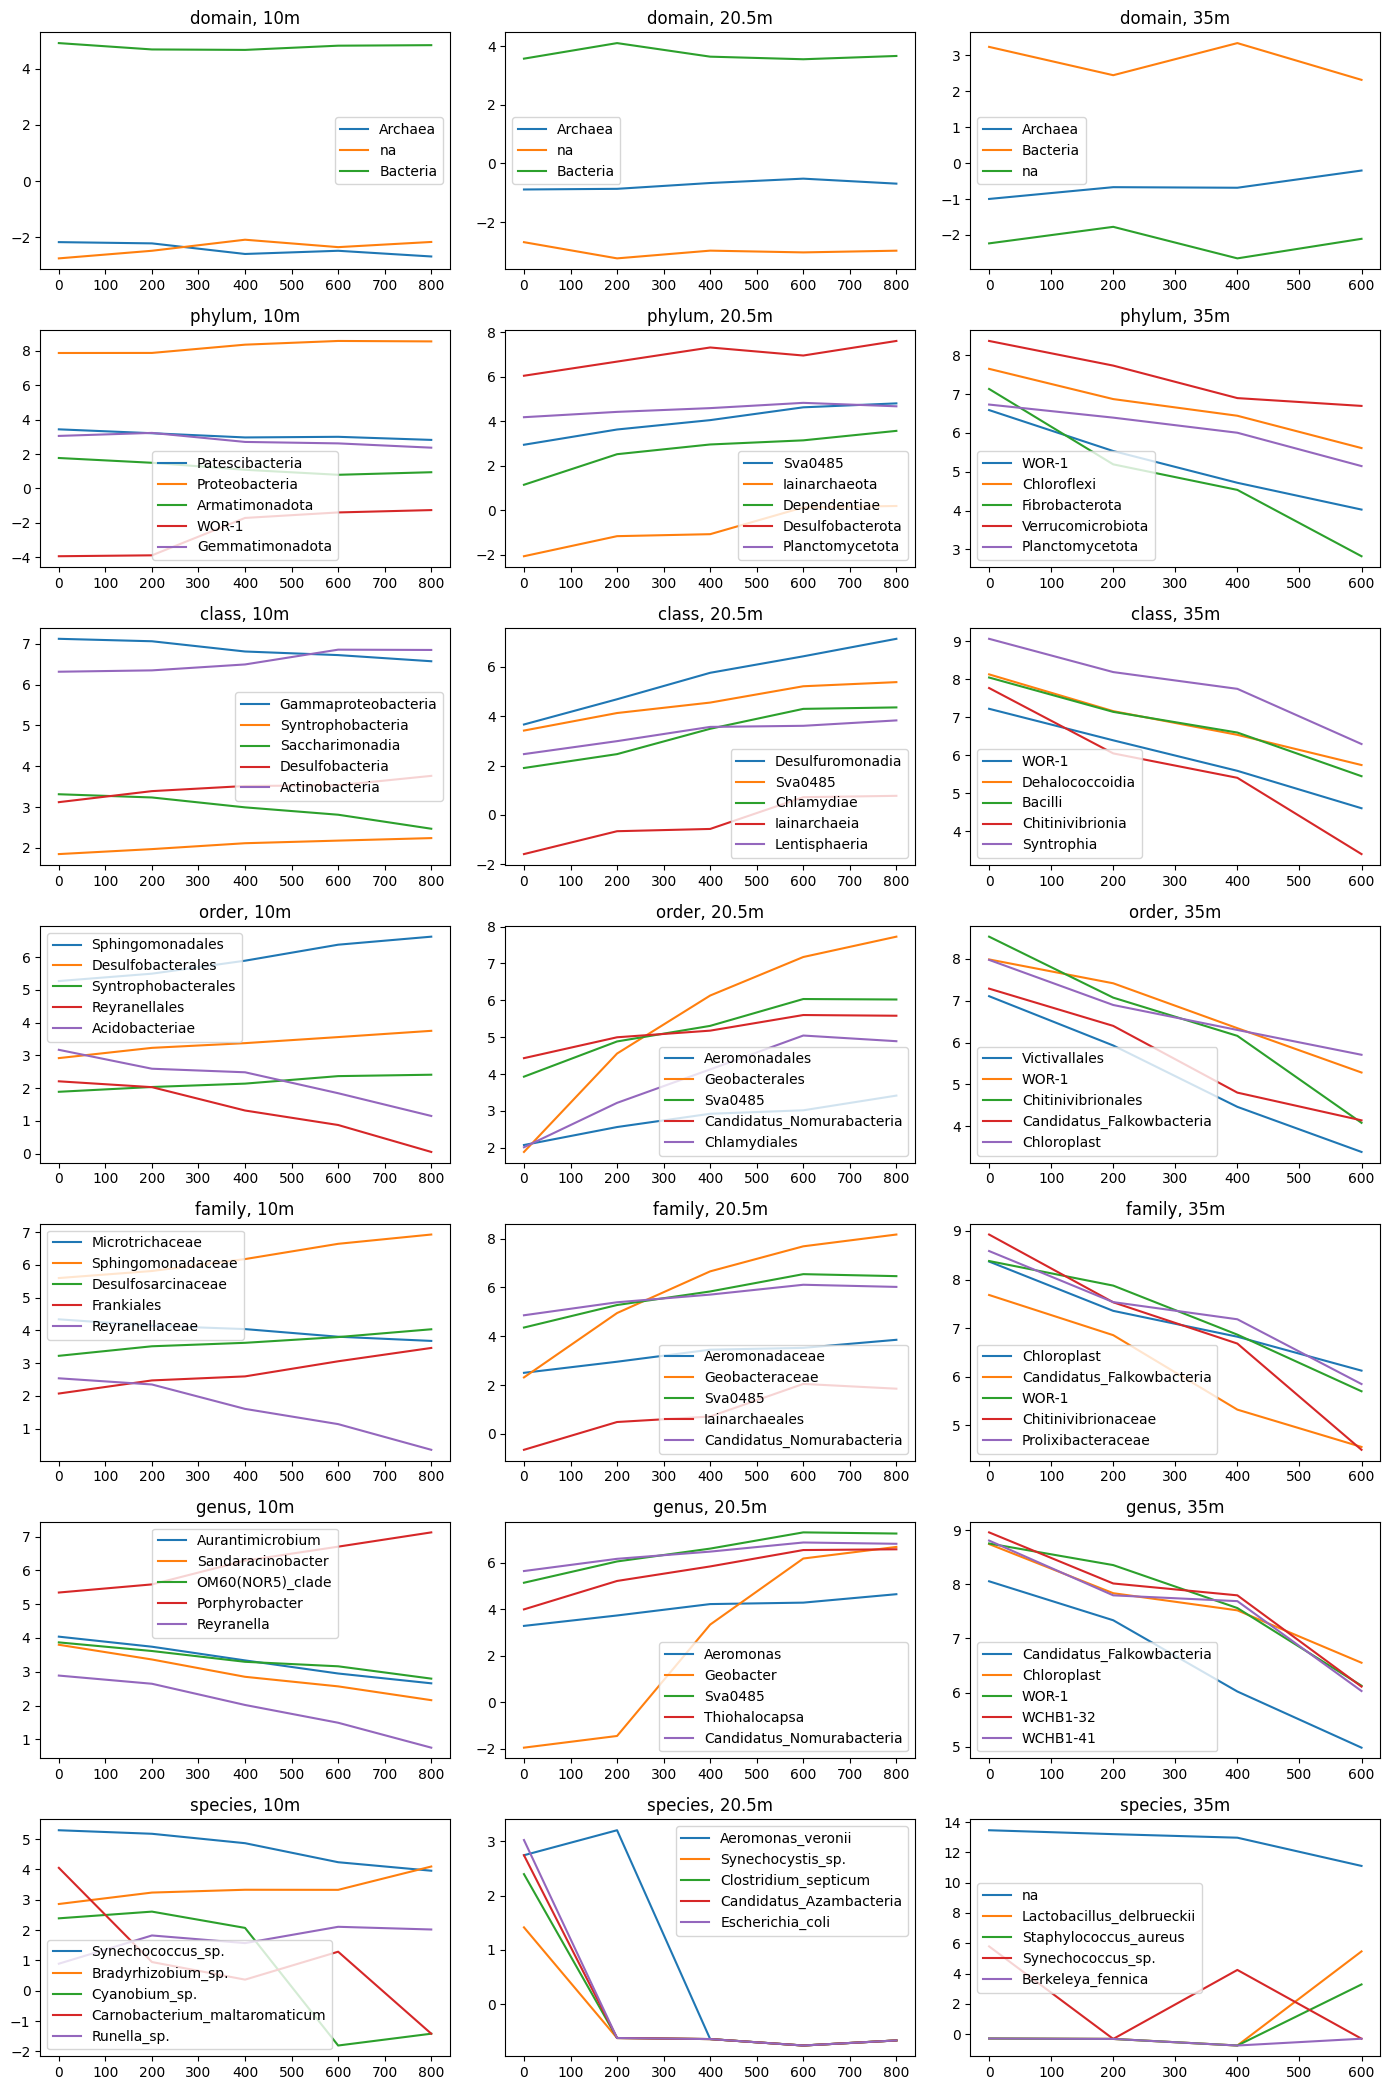

In [7]:
# MAKE A MASSIVE MULTI-CHART OF THE TOP 5 CORRELATED THINGS IN EACH LEVEL.
# GRAPHS A MULTILINE CHART WHERE EACH ROW IN DF REPRESENTS Y-VALUES
def graph_multiline(
    df, # the dataframe to graph
    x, # the x-values in the multi-line chart
    ax,
    title
):
    for idx, row in df.iterrows():
        ax.plot(x,row.values,label=idx)
    ax.set_title(title)
    return ax

fig, axes = plt.subplots(7,3,figsize=(14,21))

for i, taxon in enumerate(TAXA):
    for j, depth in enumerate(DEPTHS):
        df = grouped_by_taxa[taxon][depth].sort_values("p_value")
        df_num = df.iloc[:5,1:-2]
        graph_multiline(
            df_num,
            VOLTAGES[:df_num.shape[1]],
            axes[i][j],
            f"{taxon}, {depth}"
        )
        axes[i][j].legend()

plt.tight_layout()
plt.show()

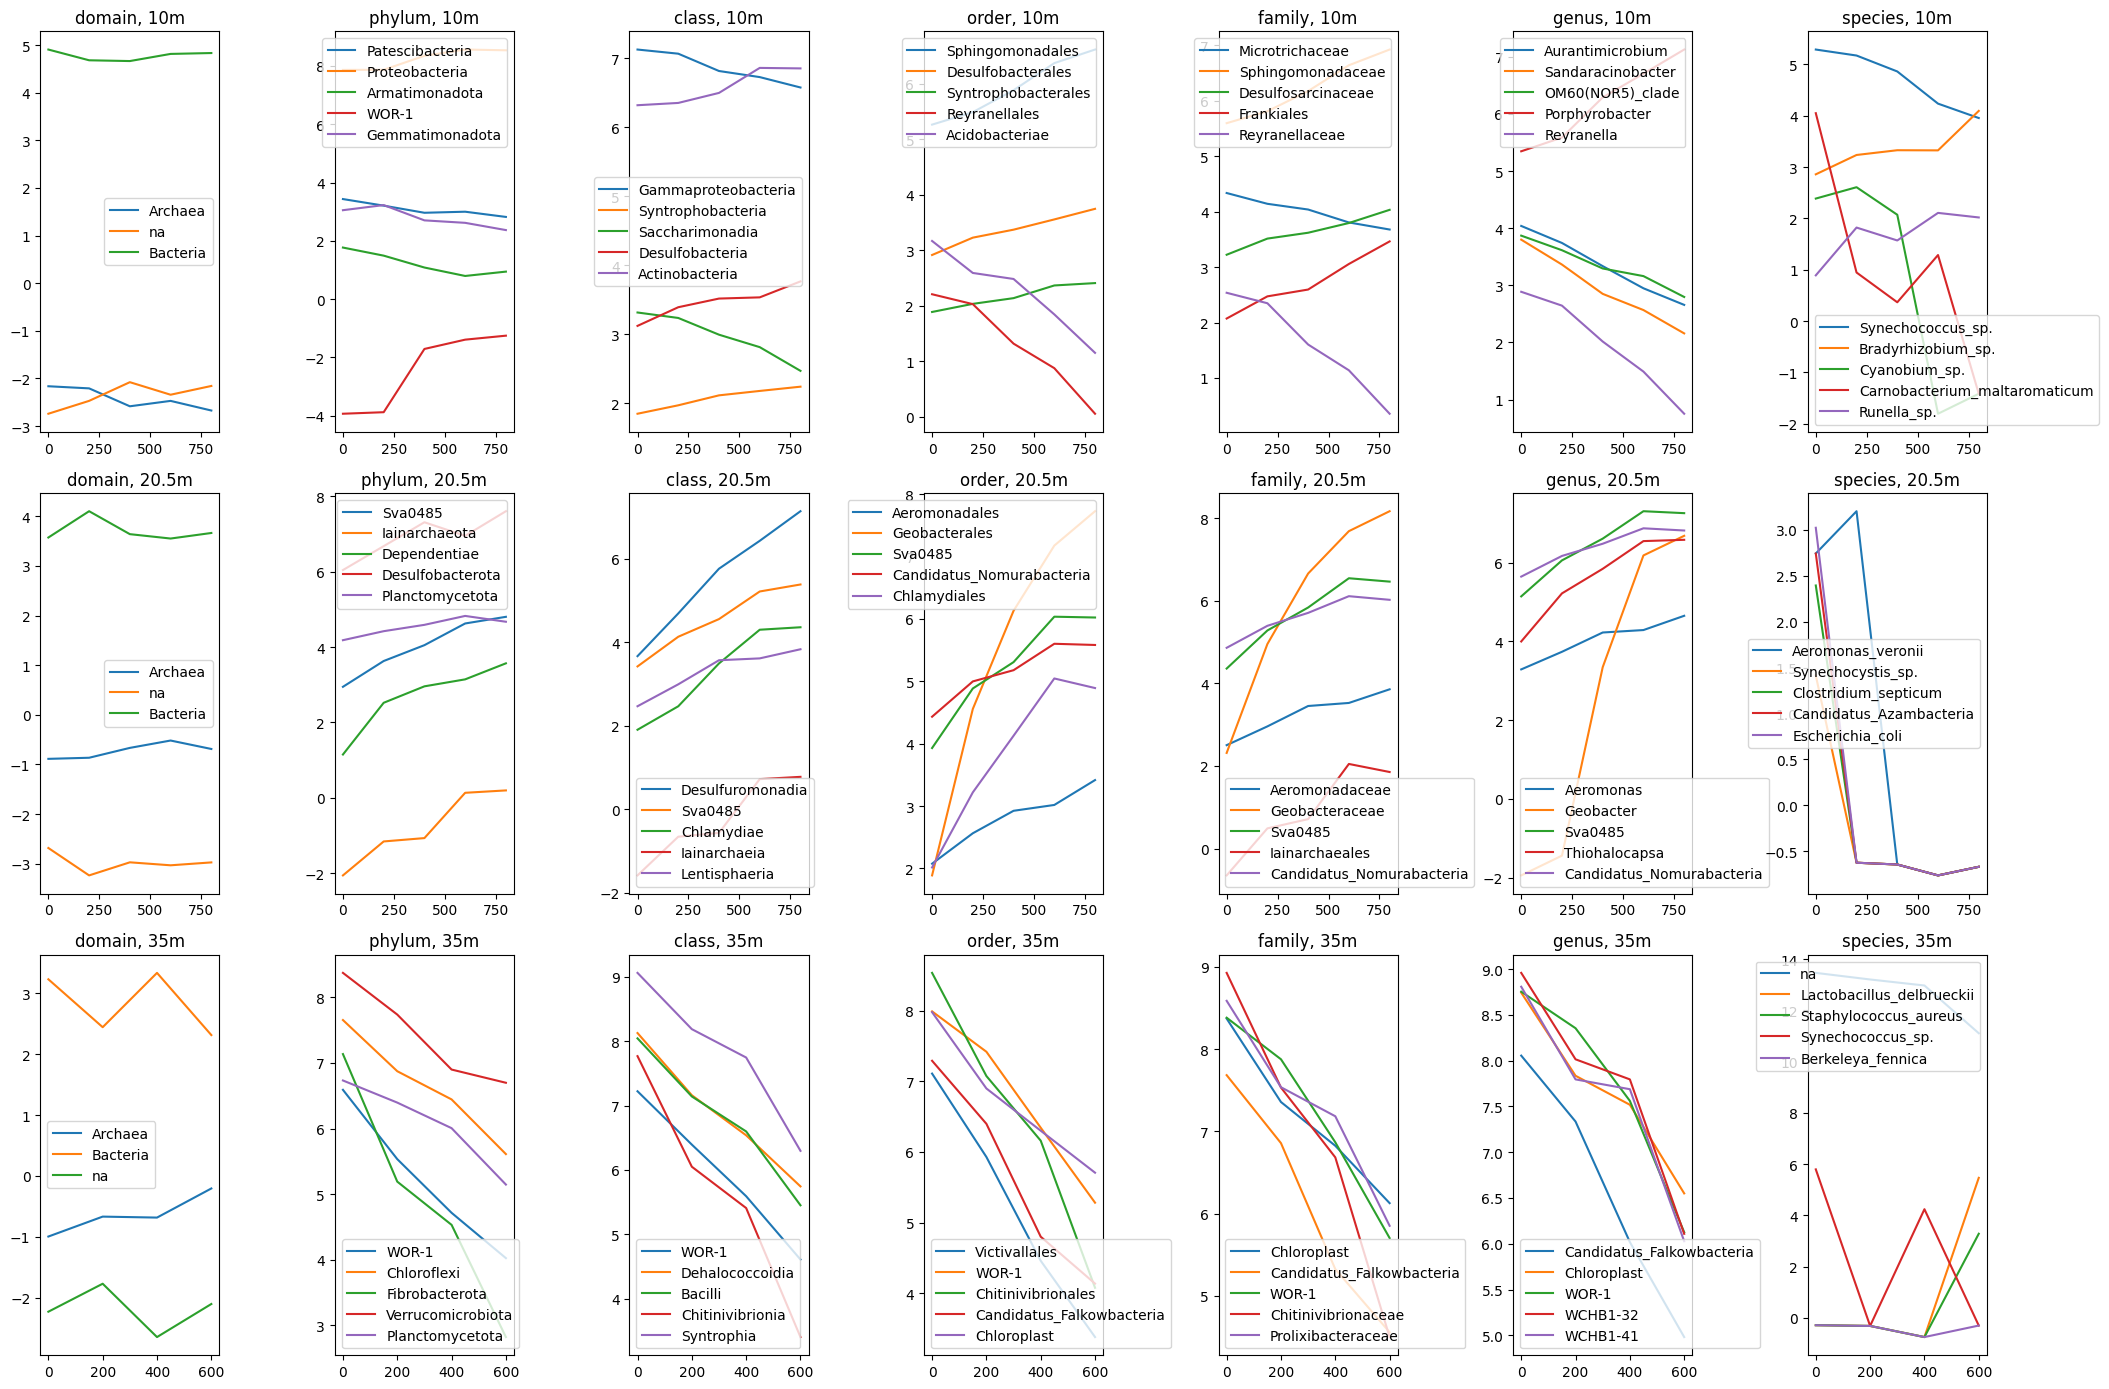

In [8]:
#HORIZONTAL PLOT CUZ MAYBE THAT WILL BE EASIER TO LOOK THROUGH
fig, axes = plt.subplots(3,7,figsize=(21,14))

for i, taxon in enumerate(TAXA):
    for j, depth in enumerate(DEPTHS):
        df = grouped_by_taxa[taxon][depth].sort_values("p_value")
        df_num = df.iloc[:5,1:-2]
        graph_multiline(
            df_num,
            VOLTAGES[:df_num.shape[1]],
            axes[j][i],
            f"{taxon}, {depth}"
        )
        axes[j][i].legend()

plt.tight_layout()
plt.show()

In [9]:
for t in TAXA:
    for d in DEPTHS:
        df = grouped_by_taxa[t][d][['r_value','p_value']]
        df = df[df['p_value'] < .05]
        print(f"{t}, {d}: Significant Correlations, p<.05")
        print("TAXA, R-VALUE, P-VALUE")
        for (idx, row) in df.iterrows():
            print(idx, round(row.values[0],4), round(row.values[1],4), sep=", ")
        print("=======================================")


domain, 10m: Significant Correlations, p<.05
TAXA, R-VALUE, P-VALUE
Archaea, -0.8969, 0.0391
domain, 20.5m: Significant Correlations, p<.05
TAXA, R-VALUE, P-VALUE
domain, 35m: Significant Correlations, p<.05
TAXA, R-VALUE, P-VALUE
phylum, 10m: Significant Correlations, p<.05
TAXA, R-VALUE, P-VALUE
Armatimonadota, -0.9202, 0.0267
Desulfobacterota, -0.8983, 0.0383
Gemmatimonadota, -0.9069, 0.0336
Myxococcota, -0.8897, 0.0433
Patescibacteria, -0.9485, 0.0139
Proteobacteria, 0.928, 0.0229
WOR-1, 0.9157, 0.029
phylum, 20.5m: Significant Correlations, p<.05
TAXA, R-VALUE, P-VALUE
Dependentiae, 0.9297, 0.0221
Desulfobacterota, 0.8916, 0.0421
Iainarchaeota, 0.9605, 0.0094
Planctomycetota, 0.8865, 0.0451
Sva0485, 0.985, 0.0022
phylum, 35m: Significant Correlations, p<.05
TAXA, R-VALUE, P-VALUE
Actinobacteriota, -0.956, 0.044
Chloroflexi, -0.9933, 0.0067
Desulfobacterota, -0.9704, 0.0296
Fibrobacterota, -0.9848, 0.0152
Planctomycetota, -0.9722, 0.0278
Proteobacteria, -0.9717, 0.0283
Verrucomicro

In [33]:
import os
for i, taxon in enumerate(TAXA):
    for j, depth in enumerate(DEPTHS):
        df = grouped_by_taxa[taxon][depth].sort_values("p_value")
        df.to_csv(f"data/{taxon}/{depth}/voltage-correlation-by-{taxon}-{depth}")

for i, taxon in enumerate(TAXA):
    for j, depth in enumerate(DEPTHS):
        df = grouped_by_taxa[taxon][depth]
        df.rename(columns={"r_value":f"r_value_{depth}", "p_value":f"p_value_{depth}"}, inplace=True)
    df = pd.concat([grouped_by_taxa[taxon][depth] for depth in DEPTHS],axis=1).T.drop_duplicates().T.head()
    df.to_csv(f"data/{taxon}/voltage-correlation-by-{taxon}-multidepth")